<a href="https://colab.research.google.com/github/debasishghosh-lab/cat-vs-dog-cnn-/blob/main/Cat_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
DATA_DIR = "https://drive.google.com/drive/folders/1Na_VJqOfTKPoF1_Uxgdjow2YDbtwYGGn?usp=drive_link"

In [13]:
import os

print(os.listdir('/content/drive/MyDrive/catvsdog/animals'))

['cat', 'dog']


In [14]:
import os
import shutil
import random

SOURCE_DIR = "/content/drive/MyDrive/catvsdog/animals"
BASE_DIR = "/content/drive/MyDrive/catvsdog/split_dataset"

random.seed(42)

for split in ["train", "validation", "test"]:
    for category in ["cat", "dog"]:
        os.makedirs(os.path.join(BASE_DIR, split, category), exist_ok=True)

for category in ["cat", "dog"]:
    source_folder = os.path.join(SOURCE_DIR, category)

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    train_end = int(len(images) * 0.70)
    val_end = train_end + int(len(images) * 0.15)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for filename in train_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(BASE_DIR, "train", category, filename)
        )

    for filename in val_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(BASE_DIR, "validation", category, filename)
        )

    for filename in test_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(BASE_DIR, "test", category, filename)
        )

In [15]:
for split in ["train", "validation", "test"]:
    print(split)

    for category in ["cat", "dog"]:
        path = os.path.join(BASE_DIR, split, category)
        print(category, len(os.listdir(path)))

train
cat 350
dog 350
validation
cat 75
dog 75
test
cat 75
dog 75


In [16]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print(class_names)

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
['cat', 'dog']


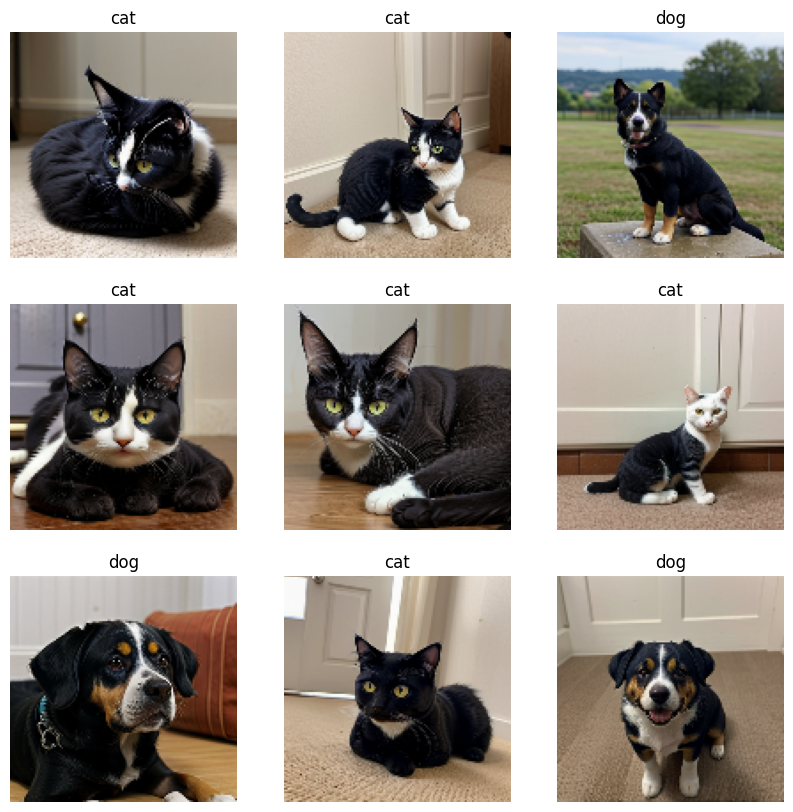

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [18]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

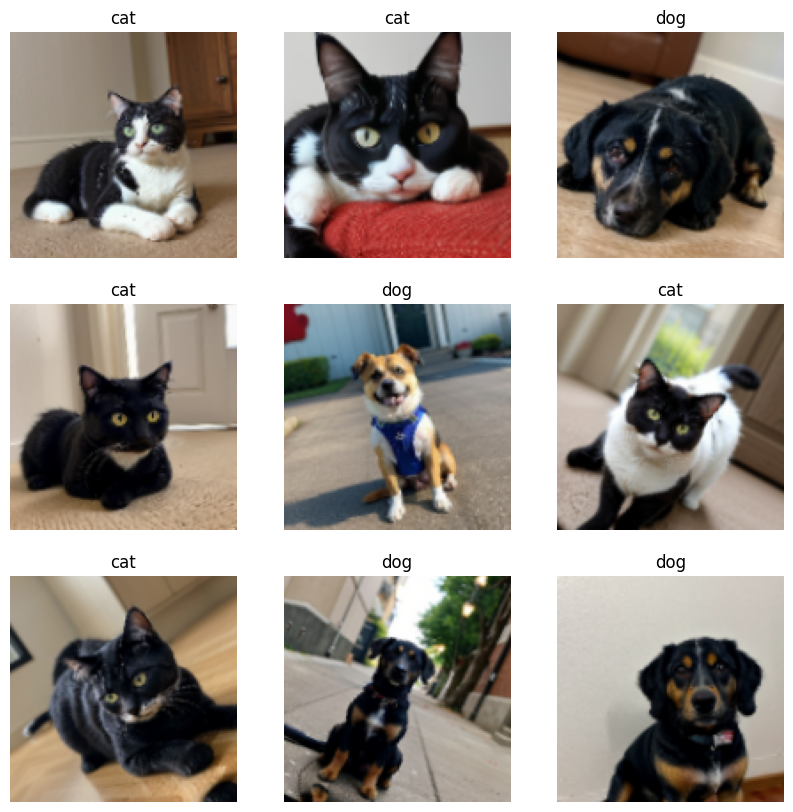

In [20]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [21]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 126, 126, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 126, 126, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (32, 126, 126, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 63, 63, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 61, 61, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 61, 61, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (32, 61, 61, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 28, 28, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 28, 28, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (32, 28, 28, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 14, 14, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 25088)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 128)              │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,177 (12.61 MB)

 Trainable params: 3,305,473 (12.61 MB)

 Non-trainable params: 704 (2.75 KB)

In [24]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 381ms/step - accuracy: 0.8129 - loss: 0.4370 - val_accuracy: 0.5000 - val_loss: 1.4483
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 361ms/step - accuracy: 0.8971 - loss: 0.2500 - val_accuracy: 0.5000 - val_loss: 1.3634
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 325ms/step - accuracy: 0.9057 - loss: 0.1982 - val_accuracy: 0.5000 - val_loss: 1.7780
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step - accuracy: 0.9414 - loss: 0.1535 - val_accuracy: 0.5000 - val_loss: 1.5886
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.9671 - loss: 0.0991 - val_accuracy: 0.5000 - val_loss: 2.2045
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.9686 - loss: 0.0877 - val_accuracy: 0.5000 - val_loss: 1.8339
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 327ms/step - accuracy: 0.9757 - loss: 0.0661 - val_accuracy: 0.5000 - val_loss: 1.3096
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.9729 - loss: 0.0862 - val_accuracy

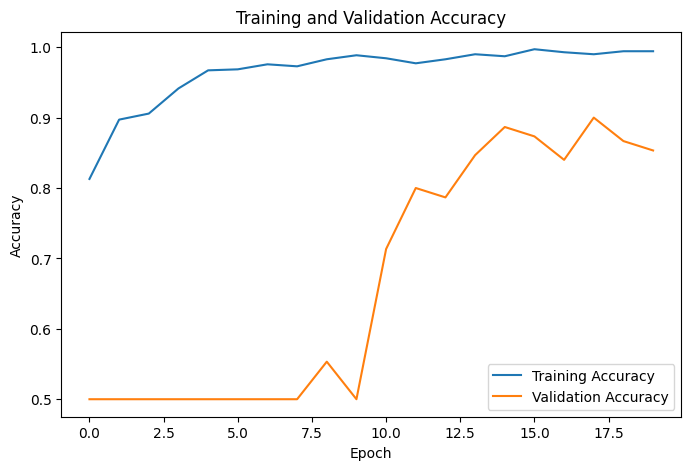

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

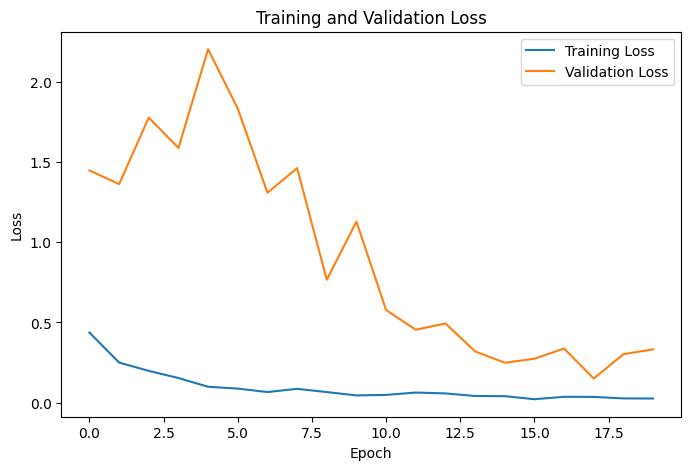

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [27]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/catvsdog/best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - accuracy: 0.9943 - loss: 0.0296 - val_accuracy: 0.9267 - val_loss: 0.1731
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 326ms/step - accuracy: 0.9914 - loss: 0.0265 - val_accuracy: 0.9533 - val_loss: 0.1088
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 337ms/step - accuracy: 0.9900 - loss: 0.0296 - val_accuracy: 0.9733 - val_loss: 0.0803
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 474ms/step - accuracy: 0.9929 - loss: 0.0256 - val_accuracy: 0.9333 - val_loss: 0.1560
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 392ms/step - accuracy: 0.9986 - loss: 0.0170 - val_accuracy: 0.9933 - val_loss: 0.0388
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 468ms/step - accuracy: 0.9914 - loss: 0.0246 - val_accuracy: 0.8867 - val_loss: 0.3151
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 407ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.9133 - val_loss: 0.2222
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 310ms/step - accuracy: 0.9914 - loss: 0.0232 - val_accuracy

In [29]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/catvsdog/best_model.keras"
)

In [30]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.9800 - loss: 0.0864
Test Loss: 0.08635349571704865
Test Accuracy: 0.9800000190734863


In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[75  0]
 [ 3 72]]


In [32]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         cat       0.96      1.00      0.98        75
         dog       1.00      0.96      0.98        75

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



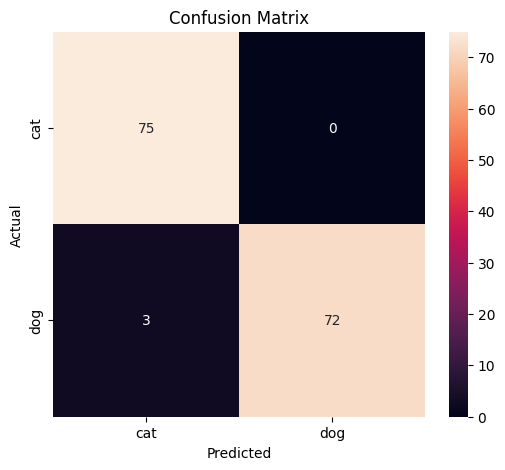

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()